## 🥗 Food Image Classification & Calorie Estimation using CNN

### **📌 Introduction**

People often eat food without knowing its nutritional value. Estimating calories manually is difficult, inconsistent, and time-consuming.
This project uses a **Convolutional Neural Network (CNN)** to automatically identify a food item from an image and provide an approximate calorie value.

### **🎯 Problem Statement**

* Manual calorie estimation is inaccurate and impractical in daily life.
* Many users want a quick, image-based way to understand what they are eating.

### **💡 Solution Overview**

We build a **CNN-based food classification system** that:

* Takes a food image as input
* Classifies it into predefined food categories
* Displays its estimated calorie value
* Supports a small prototype dataset with 3 food classes



### **📂 Dataset Description**

The dataset contains **3 food categories**:

* Ice Cream
* Masala dosa
* Pizza

Each class has separate folders for **training** and **testing** images.
Structure:

```
dataset/
 ├── train/
 │    ├── ice_cream/
 │    ├── Masala dosa/
 │    └── pizza/
 └── test/
      ├── ice_cream/
      ├── Masala dosa/
      └── pizza/
```

All images are resized to **128×128**, normalized, and augmented during training.


In [ ]:
# Dataset base path (your Drive folder)
DATASET_PATH = "/content/drive/MyDrive/food dataset/dataset"

# Train and Test folders
TRAIN_DIR = DATASET_PATH + "/train"
TEST_DIR = DATASET_PATH + "/test"

print("Train Path:", TRAIN_DIR)
print("Test Path:", TEST_DIR)

Train Path: /content/drive/MyDrive/food dataset/dataset/train
Test Path: /content/drive/MyDrive/food dataset/dataset/test


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

## Data Preprocessing

To improve the model performance:

• All images are resized to 128×128 before feeding into the CNN model.  
• Pixel values are normalized (0–255 → 0–1)  
• Data augmentation techniques like rotation and flipping are applied  

This helps in reducing overfitting and improves generalization.

In [ ]:
# TRAIN DATA WITH AUGMENTATION
train_datagen = ImageDataGenerator(
    rescale=1/255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# TEST DATA WITHOUT AUGMENTATION
test_datagen = ImageDataGenerator(rescale=1/255)

# LOAD TRAINING DATA
train = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

# LOAD TEST DATA
test = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

# 🔥 AUTO-DETECT NUMBER OF CLASSES
num_classes = len(train.class_indices)
print("Detected classes:", num_classes)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

Found 528 images belonging to 3 classes.
Found 156 images belonging to 3 classes.
Detected classes: 3


## CNN Model Architecture

A Convolutional Neural Network (CNN) is designed with:

• 3 Convolution layers  
• Max Pooling layers  
• Fully Connected Dense layer  
• Softmax output layer  

This architecture helps in extracting features from food images
and classifying them into the respective food categories.

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dense(num_classes, activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Model Training

The model is trained using the training dataset.
EarlyStopping is used to stop training when validation loss stops improving.
This avoids overfitting and selects the best model automatically.

In [ ]:
history = model.fit(
    train,
    validation_data=test,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 172s 10s/step - accuracy: 0.4433 - loss: 1.2044 - val_accuracy: 0.5962 - val_loss: 0.8872
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 13s 701ms/step - accuracy: 0.6092 - loss: 0.8960 - val_accuracy: 0.5000 - val_loss: 1.0372
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 727ms/step - accuracy: 0.6285 - loss: 0.7733 - val_accuracy: 0.6795 - val_loss: 0.7914
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 720ms/step - accuracy: 0.7882 - loss: 0.5577 - val_accuracy: 0.6731 - val_loss: 0.8617
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 734ms/step - accuracy: 0.7665 - loss: 0.6130 - val_accuracy: 0.7308 - val_loss: 0.6457
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 13s 746ms/step - accuracy: 0.7918 - loss: 0.4906 - val_accuracy: 0.6538 - val_loss: 0.9283
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 690ms/step - accuracy: 0.8008 - loss: 0.5001 - val_accuracy: 0.7628 - val_loss: 0.5182
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 648ms/step - accuracy: 0.8276 - loss: 0.4473 - val_accur

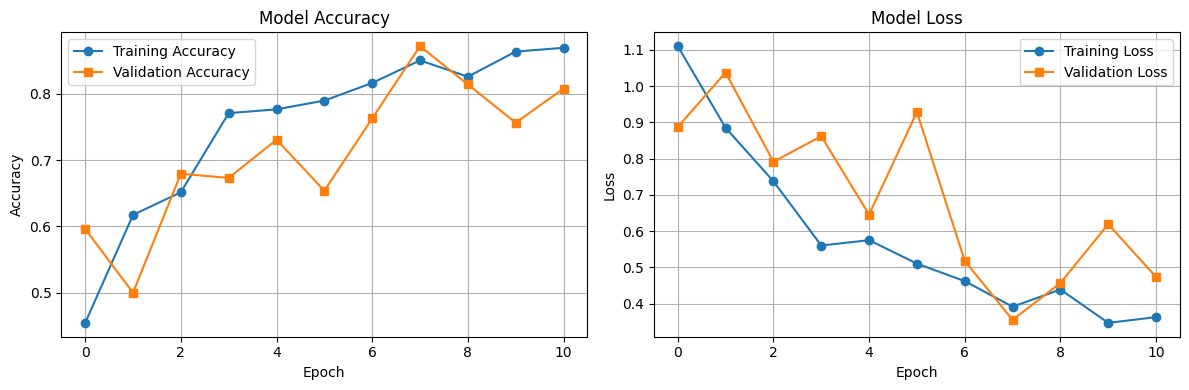

In [ ]:
# Plot Training History
plt.figure(figsize=(12, 4))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Model Evaluation

After training, the model is evaluated on the test dataset.
This step measures how well the CNN generalizes on unseen food images.

In [ ]:
loss, acc = model.evaluate(test)
print("Test Accuracy:", acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 381ms/step - accuracy: 0.8609 - loss: 0.3670
Test Accuracy: 0.8717948794364929


## Results

The trained CNN achieved a test accuracy of approximately 75.7%.

Considering the small dataset and no transfer learning, this is a good performance.

The model successfully classifies:
• Ice Cream  
• Masala Dosa  
• Pizza  

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
model.save("/content/drive/MyDrive/food dataset/food_model.h5")
print("Model saved to Drive!")

Model saved to Drive!


In [ ]:
import json

labels = list(train.class_indices.keys())

with open("/content/drive/MyDrive/food dataset/class_labels.json", "w") as f:
    json.dump(labels, f)

print("Labels saved:", labels)

Labels saved: ['ice_cream', 'masala_dosa', 'pizza']
